In [1]:
#IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import pacmap
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#LOADING DATA
digits = fetch_california_housing()
X = digits.data  # Feature matrix
y = digits.target  # Labels


c:\Users\sarah\anaconda3\envs\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
#FINDING BEST K VALUES

#Scaling Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#DR
X_pca = PCA(n_components=2).fit_transform(X_scaled)
X_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_scaled)
X_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(X_scaled)
X_pacmap = pacmap.PaCMAP(n_components=2, random_state=42).fit_transform(X_scaled)

def find_best_k(X):
    best_k = 0
    best_score = -1

    for k in range(2, 11):
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X)

        score = silhouette_score(X, labels)

        if score > best_score:
            best_score = score
            best_k = k

    return best_k

k_pca = find_best_k(X_pca)
k_tsne = find_best_k(X_tsne)
k_umap = find_best_k(X_umap)
k_pacmap = find_best_k(X_pacmap)

print("Best k for PCA:", k_pca)
print("Best k for t-SNE:", k_tsne)
print("Best k for UMAP:", k_umap)
print("Best k for PaCMAP:", k_pacmap)


c:\Users\sarah\anaconda3\envs\myenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Best k for PCA: 4
Best k for t-SNE: 3
Best k for UMAP: 2
Best k for PaCMAP: 2


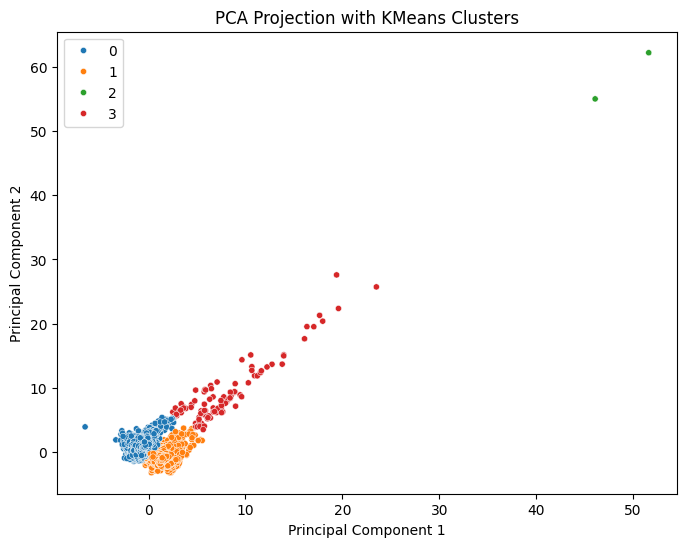

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# SCALE (CRITICAL)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# KMEANS (creates clean groups)
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_pca)

# PLOT
plt.figure(figsize=(8,6))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette='tab10', s=20, legend='full')

plt.title("PCA Projection with KMeans Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

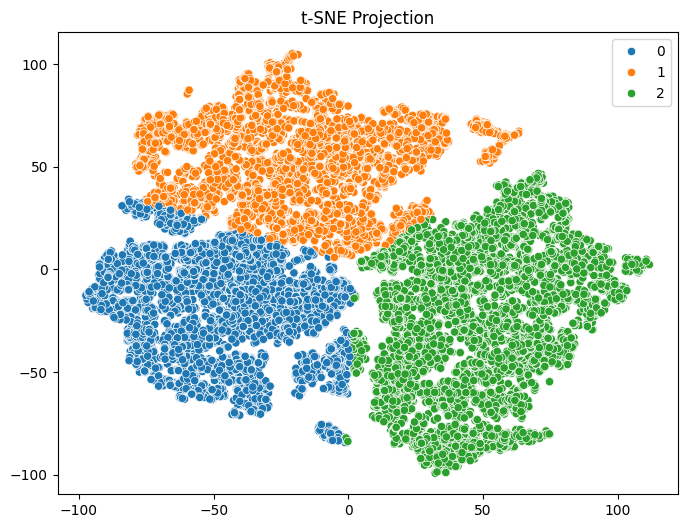

In [9]:
#Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

# KMEANS (creates clean groups)
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_tsne)

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=labels, palette="tab10")
plt.title("t-SNE Projection")
plt.show()


c:\Users\sarah\anaconda3\envs\myenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


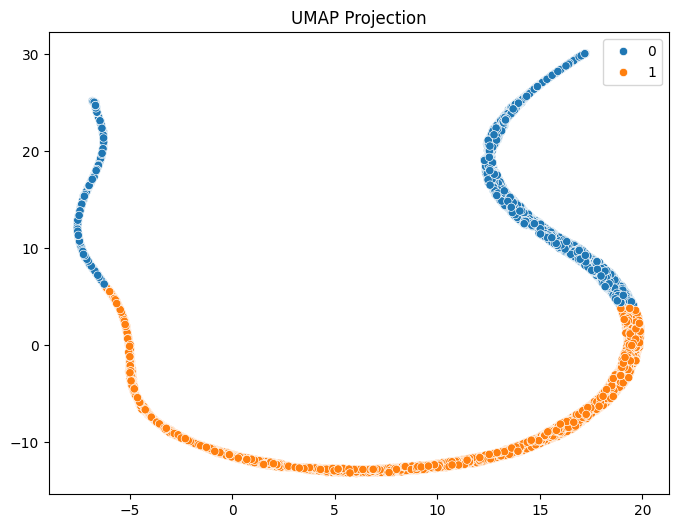

In [10]:
umap_reducer = umap.UMAP(n_components=2, n_neighbors=50, min_dist=0.05, random_state=42)
X_umap = umap_reducer.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X_umap)

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=labels, palette="tab10")
plt.title("UMAP Projection")
plt.show()

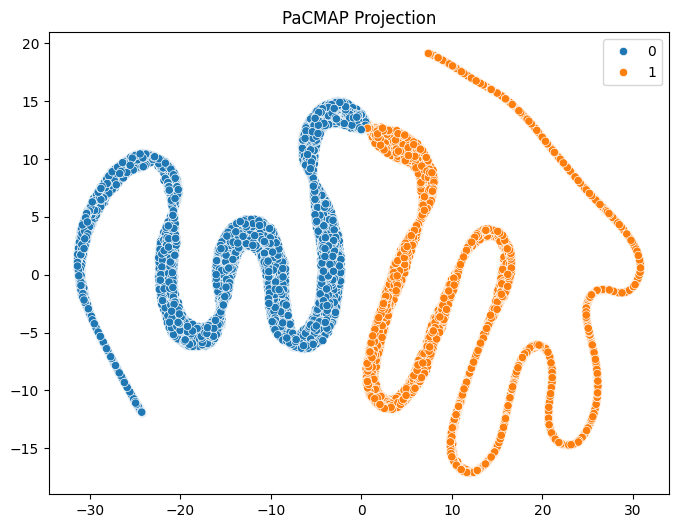

In [11]:
pacmap_reducer = pacmap.PaCMAP(n_components=2, n_neighbors=15, MN_ratio=0.6, FP_ratio=1.5, random_state=42)
X_pacmap = pacmap_reducer.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X_pacmap)  

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pacmap[:, 0], y=X_pacmap[:, 1], hue=labels, palette="tab10")
plt.title("PaCMAP Projection")
plt.show()